# Perersistence homology for small molecules

Some small molecule examples to demonstrate how persistence diagrams work

Source of more small modlecules with pdb structures:
https://ww2.chemistry.gatech.edu/~lw26/structure/small_molecules/index.html

In [194]:
# lets load our libraries
#!conda install -y -c conda-forge numpy=1.19.5
import deepchem as dc
from rdkit import Chem
from rdkit.Chem import Draw
import tensorflow as tf
import os
import sys
import rdkit
import h5py
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri 
import rdkit.Chem
import rdkit.Chem.AllChem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff 
from gtda.mapper import plot_interactive_mapper_graph
from gtda.plotting import plot_point_cloud, plot_betti_curves
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

from pathlib import Path

_base_dir = Path.cwd().parent
_src_dir = str(_base_dir / "src")
if _src_dir not in sys.path:
    sys.path.append(_src_dir)

import helper_functions as h


base_dir = Path.cwd().resolve().parent 
results_dir = base_dir / "output" / "results" / "small_molecule"
data_dir = base_dir / "datasets" / "small_molecule"



TensorFlow version: 2.19.0


In [105]:
#Note: These functions are all included in the helper_functions in the .src directory and jsut copied here for interest

def generate_structure_from_smiles(smiles):

    # Generate a 3D structure from smiles

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)

    status = AllChem.EmbedMolecule(mol)
    status = AllChem.UFFOptimizeMolecule(mol)

    conformer = mol.GetConformer()
    coordinates = conformer.GetPositions()
    coordinates = np.array(coordinates)

    #atoms = get_atoms(mol)

    return coordinates 

def smiles_to_persistence_diagrams(smiles):
    coords=generate_structure_from_smiles(smiles)
    # makes a point cloud version of the structure
    # there are no atom types

    # Track connected components, loops, and voids
    homology_dimensions = [0, 1, 2]

    # Collapse edges to speed up H2 persistence calculation!
    persistence = VietorisRipsPersistence(
        metric="euclidean",
        homology_dimensions=homology_dimensions,
        n_jobs=6,
        collapse_edges=True,
    )
    reshaped_coords=coords[None, :, :]
    diagrams_basic = persistence.fit_transform(reshaped_coords)
    return coords, diagrams_basic

def generate_structure_from_pdb(data_dir,
                               filename):

    # Generate a 3D structure from smiles

    mol = rdkit.Chem.rdmolfiles.MolFromPDBFile(
        os.path.join(data_dir, filename))
    mol = Chem.AddHs(mol)

    status = AllChem.EmbedMolecule(mol)
    status = AllChem.UFFOptimizeMolecule(mol)

    conformer = mol.GetConformer()
    coordinates = conformer.GetPositions()
    coordinates = np.array(coordinates)

    #atoms = get_atoms(mol)

    return coordinates 

def generate_structure_from_mol(data_dir,
                               filename):

    # Generate a 3D structure from smiles

    mol = rdkit.Chem.rdmolfiles.MolFromMolFile(
        os.path.join(data_dir, filename))
    mol = Chem.AddHs(mol)

    status = AllChem.EmbedMolecule(mol)
    status = AllChem.UFFOptimizeMolecule(mol)

    conformer = mol.GetConformer()
    coordinates = conformer.GetPositions()
    coordinates = np.array(coordinates)

    #atoms = get_atoms(mol)

    return coordinates

def coords_to_persistence_diagrams(coords):
    # makes a point cloud version of the structure
    # there are no atom types

    # Track connected components, loops, and voids
    homology_dimensions = [0, 1, 2]

    # Collapse edges to speed up H2 persistence calculation!
    persistence = VietorisRipsPersistence(
        metric="euclidean",
        homology_dimensions=homology_dimensions,
        n_jobs=6,
        collapse_edges=True,
    )
    reshaped_coords=coords[None, :, :]
    diagrams_basic = persistence.fit_transform(reshaped_coords)
    return coords, diagrams_basic

## Testing out some simple compounds

Here we use SMILES strings and rdkit minimisation to get molecular structure as 3-D coordinates, then create point clouds, persistence diagrams and finally PHF features.

In [107]:
benzene = rdkit.Chem.MolFromSmiles("c1ccccc1")
benzene_smiles = "c1ccccc1"
cyclohexane = rdkit.Chem.MolFromSmiles("C1CCCCC1")
cyclohexane_smiles = "C1CCCCC1"
pyridine = rdkit.Chem.MolFromSmiles("n1ccccc1") 
pyridine_smiles = "n1ccccc1"
furan = rdkit.Chem.MolFromSmiles("o1cccc1")
furan_smiles = "o1cccc1"

bucky_ball_smiles = "c12c3c4c5c1c1c6c7c2c2c8c3c3c9c4c4c%10c5c5c1c1c6c6c%11c7c2c2c7c8c3c3c8c9c4c4c9c%10c5c5c1c1c6c6c%11c2c2c7c3c3c8c4c4c9c5c1c1c6c2c3c41"
bucky_ball= rdkit.Chem.MolFromSmiles(bucky_ball_smiles)
bucky_ball
S_alanine_smiles='C[C@@H](C(=O)O)N'
S_alanine = rdkit.Chem.MolFromSmiles(S_alanine_smiles)
D_alanine_smiles='C[C@H](C(=O)O)N'
D_alanine = rdkit.Chem.MolFromSmiles(D_alanine_smiles)
hexane_smiles = 'CCCCCC'
hexane= rdkit.Chem.MolFromSmiles('CCCCCC')


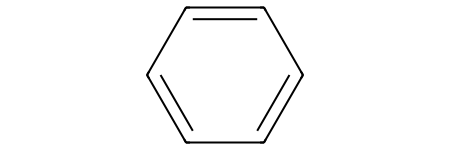

In [108]:
benzene

### Benzene
It looks like information about the bond lengths are included.

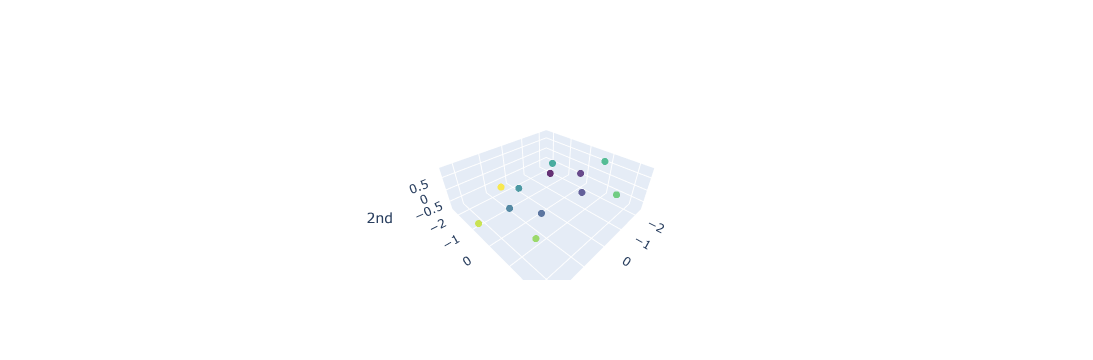

In [109]:
coords, diagrams_basic = smiles_to_persistence_diagrams(benzene_smiles)
plot_point_cloud(coords)

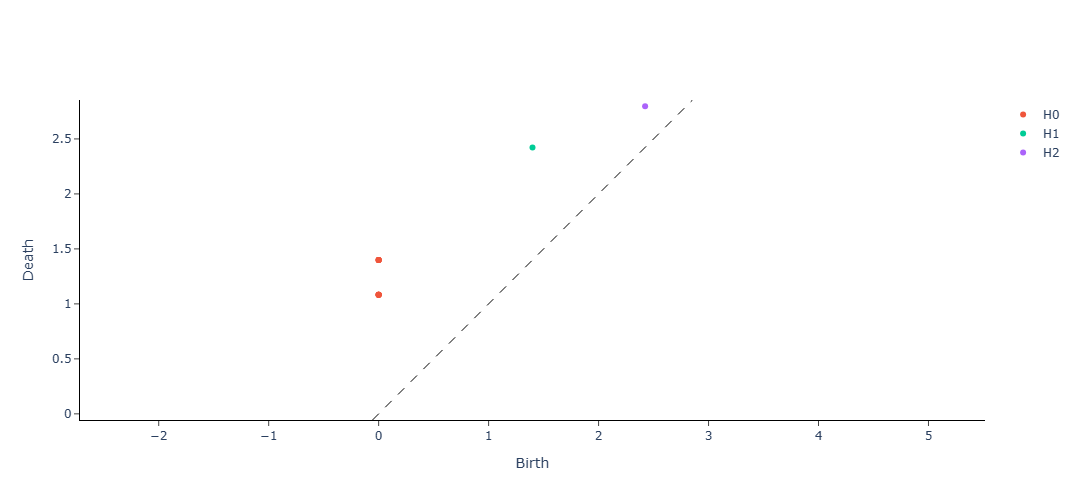

In [110]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

This is interesting, there are 6 CH bonds at about 1.09A, and we have 6 features dying at 1.08, these are the bonds. Then we have the C=C bonds dying at 1.39, 6-1 cos the remaining feature is the ring, which dies at 1.399 and then I think the entire thing collapes into a point at 2.42

## Making a barcode plot

In [115]:
diagrams_basic

array([[[0.        , 1.08233905, 0.        ],
        [0.        , 1.08233905, 0.        ],
        [0.        , 1.08233905, 0.        ],
        [0.        , 1.08233905, 0.        ],
        [0.        , 1.08233905, 0.        ],
        [0.        , 1.08233905, 0.        ],
        [0.        , 1.39904296, 0.        ],
        [0.        , 1.39904296, 0.        ],
        [0.        , 1.39904296, 0.        ],
        [0.        , 1.39904296, 0.        ],
        [0.        , 1.39904308, 0.        ],
        [1.39904308, 2.42321348, 1.        ],
        [2.42321348, 2.79808593, 2.        ]]])

In [116]:
x_val_a = [x for x in diagrams_basic[0][:,0]]
x_val_b = [x for x in diagrams_basic[0][:,1]]
y_val = [-x for x in range(len(x_val_a))]
col = [int(x) for x in diagrams_basic[0][:,2]]

In [117]:
col=['r','r','r','r','r','r','r','r','r','r','r','b','g']

([], [])

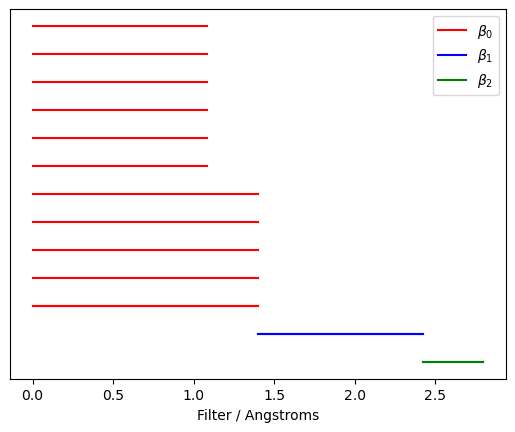

In [118]:
for i in range(3,0,-1):
    plt.plot([x_val_a[-i],x_val_b[-i]],[y_val[-i],y_val[-i]], c=col[-i])
plt.legend([r'$\beta_0$',r'$\beta_1$',r'$\beta_2$'])
for i in range(len(x_val_a)):
    plt.plot([x_val_a[i],x_val_b[i]],[y_val[i],y_val[i]], c=col[i])
plt.xlabel('Filter / Angstroms')
plt.yticks([])


## Featursing the persistence plot to persistent homology features

In [121]:
persistence_entropy = PersistenceEntropy()

# calculate topological feature matrix
X_basic = persistence_entropy.fit_transform(diagrams_basic)

# expect shape - (n_point_clouds, n_homology_dims)
X_basic.shape

(1, 3)

In [122]:
X_basic

array([[3.4475629, 0.       , 0.       ]])

In [123]:
from gtda.diagrams import Amplitude

Amplitude(metric='bottleneck').fit_transform(diagrams_basic)

array([[0.69952154, 0.5120852 , 0.18743622]])

In [124]:
Amplitude(metric='wasserstein').fit_transform(diagrams_basic)

array([[2.05032639, 0.5120852 , 0.18743622]])

In [125]:
Amplitude(metric='landscape').fit_transform(diagrams_basic)

array([[0.47767647, 0.29918895, 0.06625406]])

In [126]:
Amplitude(metric='persistence_image').fit_transform(diagrams_basic)

array([[12.83646931,  1.4666147 ,  0.        ]])

In [127]:
from gtda.diagrams import NumberOfPoints

# Reshape single diagram to (n_samples, n_features, 3) format
diagram = diagrams_basic[0][None, :, :]
# Get number of points for (H0, H1, H2)
NumberOfPoints().fit_transform(diagram)

array([[11,  1,  1]], dtype=int64)

In [128]:
from sklearn.pipeline import make_union

# Select a variety of metrics to calculate amplitudes
metrics = [
    {"metric": metric}
    for metric in ["bottleneck", "wasserstein", "landscape", "persistence_image"]
]

# Concatenate to generate 3 + 3 + (4 x 3) = 18 topological features
feature_union = make_union(
    PersistenceEntropy(normalize=True),
    NumberOfPoints(n_jobs=-1),
    *[Amplitude(**metric, n_jobs=-1) for metric in metrics]
)
feature_union

FeatureUnion(transformer_list=[('persistenceentropy',
                                PersistenceEntropy(normalize=True)),
                               ('numberofpoints', NumberOfPoints(n_jobs=-1)),
                               ('amplitude-1',
                                Amplitude(metric='bottleneck', n_jobs=-1)),
                               ('amplitude-2',
                                Amplitude(metric='wasserstein', n_jobs=-1)),
                               ('amplitude-3', Amplitude(n_jobs=-1)),
                               ('amplitude-4',
                                Amplitude(metric='persistence_image',
                                          n_jobs=-1))])

In [129]:
from gtda.pipeline import Pipeline
from gtda.mapper import plot_interactive_mapper_graph
steps = [
    ("persistence", VietorisRipsPersistence(metric="euclidean", homology_dimensions=[0,1,2], n_jobs=6)),
    ("entropy", PersistenceEntropy()),
    ("model", RandomForestRegressor(oob_score=True)),
]

pipeline = Pipeline(steps)

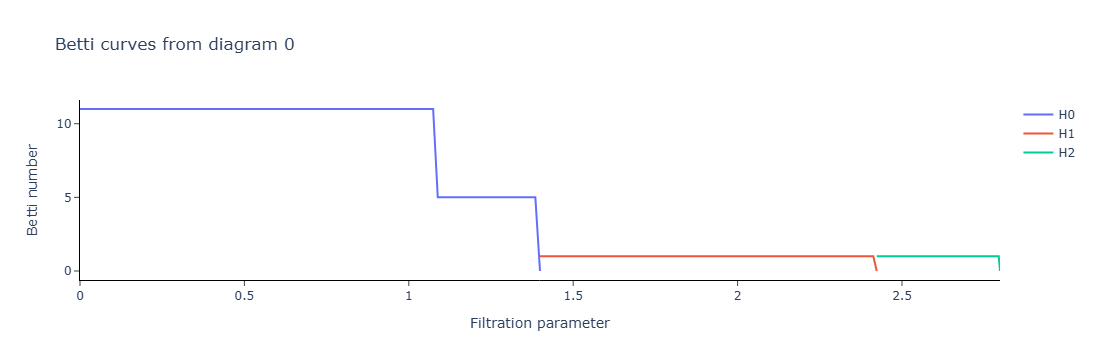

In [130]:
from gtda.diagrams import Scaler, Filtering, PersistenceEntropy, BettiCurve, PairwiseDistance

BC = BettiCurve()

X_betti_curves = BC.fit_transform(diagrams_basic)

BC.plot(X_betti_curves)

In [131]:
X_betti_curves

array([[[11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
         11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
         11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
         11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
         11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,  5,  5,  5,
          5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
          5,  5,  5,  0],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  0],
        [ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,

## Other small molecules

## pyridine

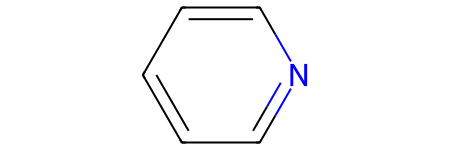

In [132]:
pyridine

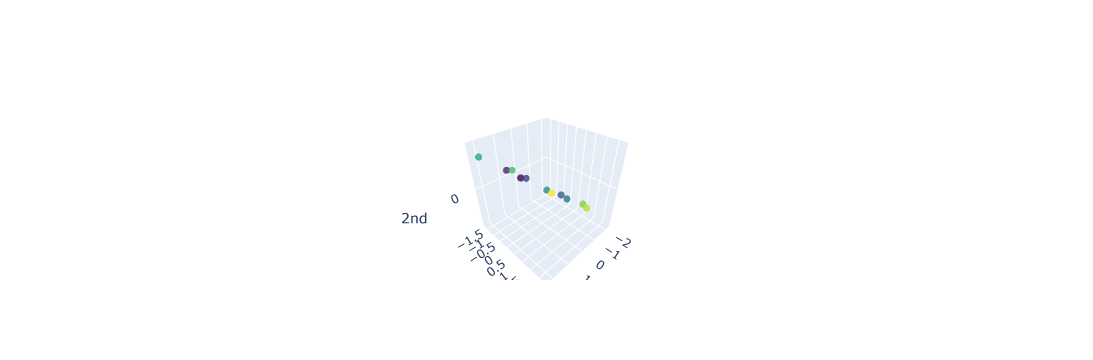

In [133]:
coords, diagrams_basic = smiles_to_persistence_diagrams(pyridine_smiles)
plot_point_cloud(coords)

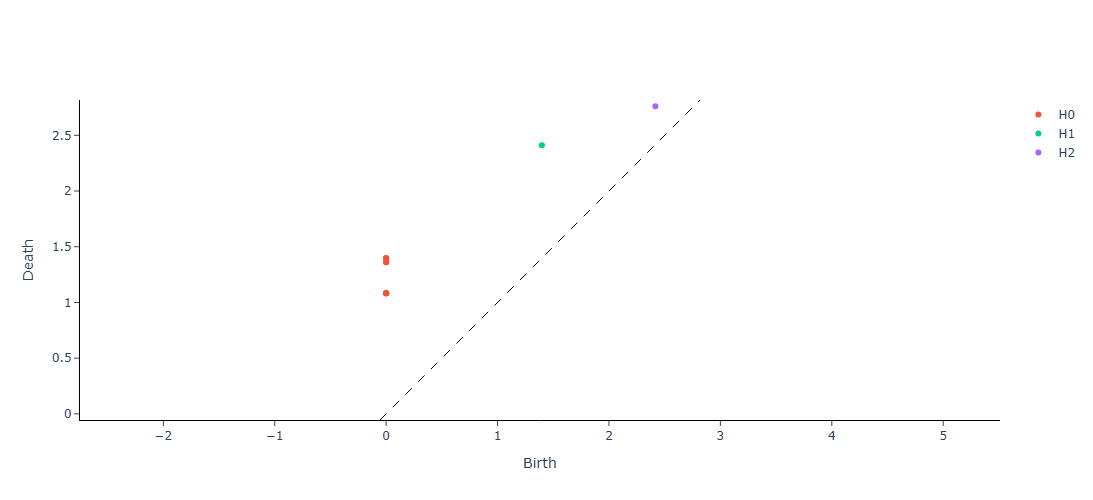

In [134]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

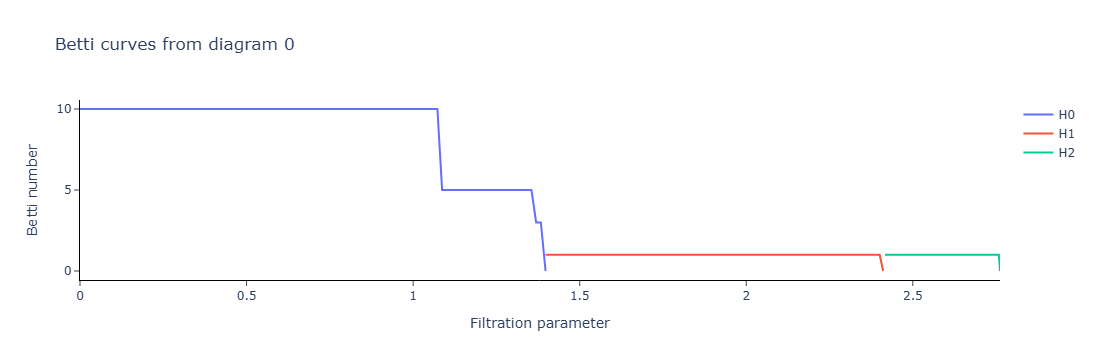

In [135]:
BC = BettiCurve()

X_betti_curves = BC.fit_transform(diagrams_basic)

BC.plot(X_betti_curves)

Pyridine values:
5 CH at around 1.08, but they are not exactly the same, 2 pairs, 2 pairs and one, this is the pairs of C-H, so this method is capturing the difference between different environments.
Then 2 at 1.36, then 2 at 1.39, one at 1.39ish - that's gotta be 5 of the 6 C-C or C-N bonds (the ring)
then ring close and 
molecule become a blob

In [136]:
diagrams_basic

array([[[0.        , 1.08179998, 0.        ],
        [0.        , 1.08179998, 0.        ],
        [0.        , 1.08231044, 0.        ],
        [0.        , 1.08231044, 0.        ],
        [0.        , 1.08233058, 0.        ],
        [0.        , 1.36050916, 0.        ],
        [0.        , 1.36050916, 0.        ],
        [0.        , 1.39675403, 0.        ],
        [0.        , 1.39675403, 0.        ],
        [0.        , 1.39756441, 0.        ],
        [1.39756441, 2.41083002, 1.        ],
        [2.41668129, 2.7617209 , 2.        ]]])

## furan

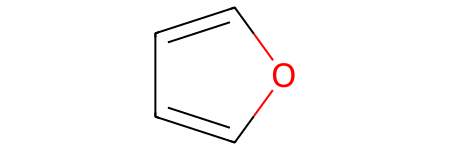

In [137]:
furan

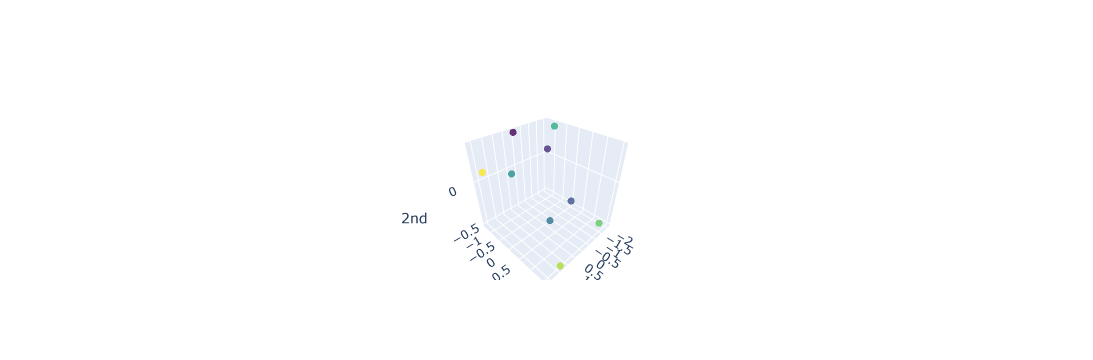

In [138]:
coords, diagrams_basic = smiles_to_persistence_diagrams(furan_smiles)
plot_point_cloud(coords)

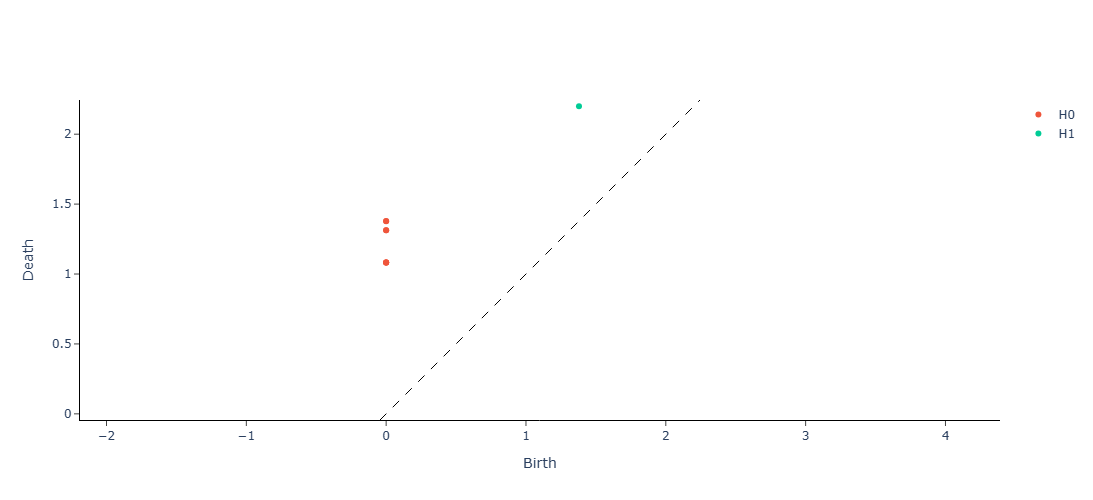

In [139]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

In [47]:
diagrams_basic

array([[[0.        , 1.08174658, 0.        ],
        [0.        , 1.08174658, 0.        ],
        [0.        , 1.08177471, 0.        ],
        [0.        , 1.08177471, 0.        ],
        [0.        , 1.31312513, 0.        ],
        [0.        , 1.31312513, 0.        ],
        [0.        , 1.37776423, 0.        ],
        [0.        , 1.37902129, 0.        ],
        [1.37902129, 2.2005055 , 1.        ],
        [0.        , 0.        , 2.        ]]])

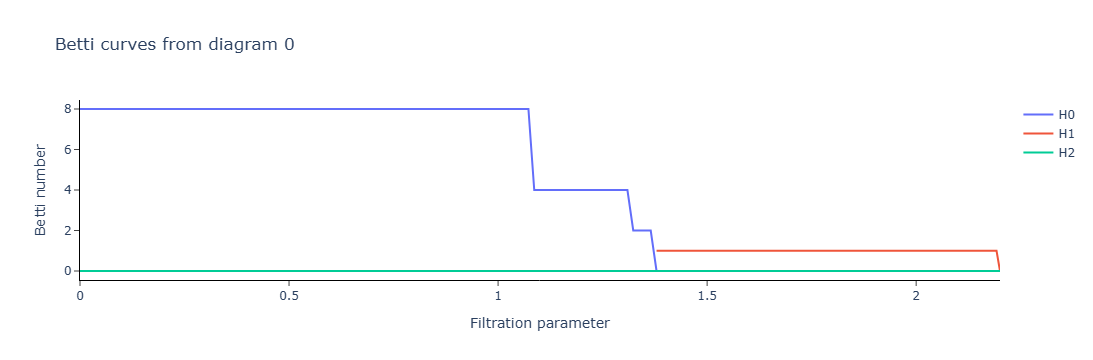

In [48]:
BC = BettiCurve()

X_betti_curves = BC.fit_transform(diagrams_basic)

BC.plot(X_betti_curves)

## cyclohexane
you need to do this with boat and chair conformation

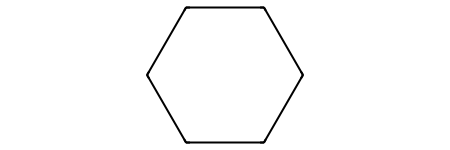

In [49]:
cyclohexane

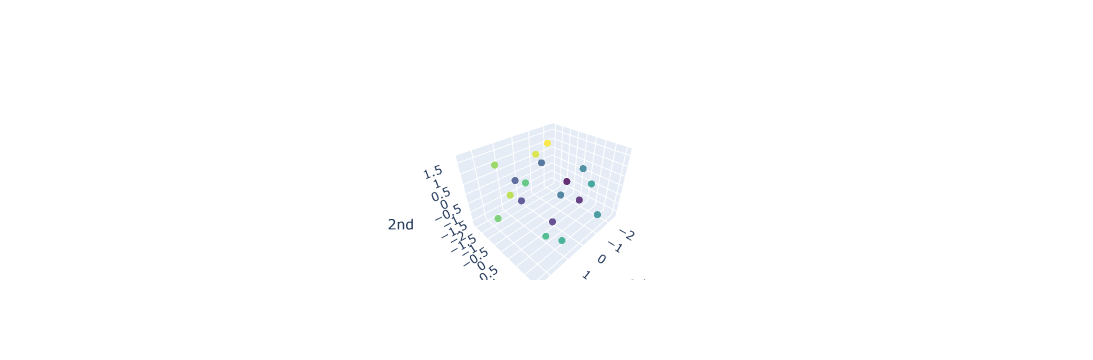

In [50]:
coords, diagrams_basic = smiles_to_persistence_diagrams(cyclohexane_smiles)
plot_point_cloud(coords)

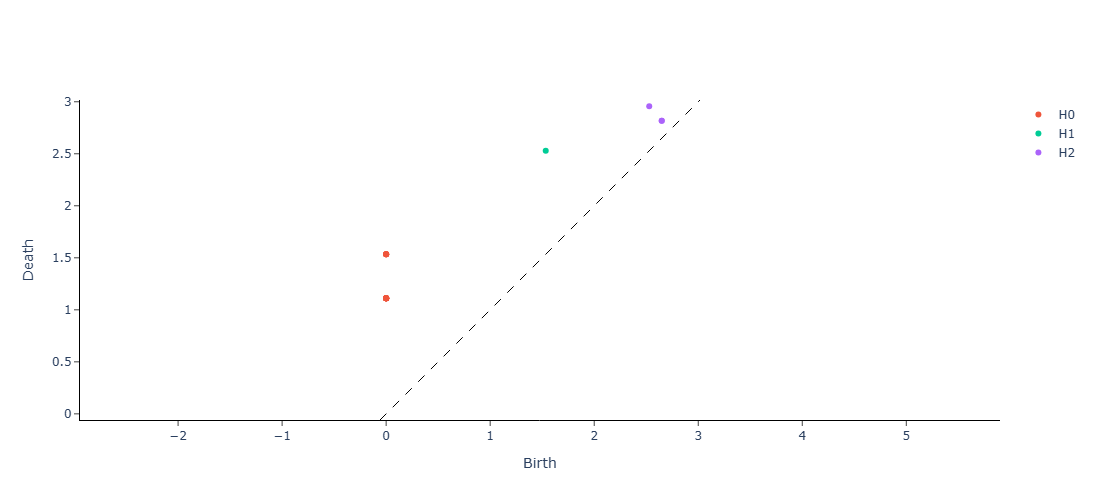

In [51]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

In [52]:
diagrams_basic

array([[[0.        , 1.11122668, 0.        ],
        [0.        , 1.11122692, 0.        ],
        [0.        , 1.11122704, 0.        ],
        [0.        , 1.11122715, 0.        ],
        [0.        , 1.11122739, 0.        ],
        [0.        , 1.11122751, 0.        ],
        [0.        , 1.11231875, 0.        ],
        [0.        , 1.11231887, 0.        ],
        [0.        , 1.11231887, 0.        ],
        [0.        , 1.11231899, 0.        ],
        [0.        , 1.11231923, 0.        ],
        [0.        , 1.11231935, 0.        ],
        [0.        , 1.53396952, 0.        ],
        [0.        , 1.53396964, 0.        ],
        [0.        , 1.53396976, 0.        ],
        [0.        , 1.53396988, 0.        ],
        [0.        , 1.53396988, 0.        ],
        [1.53397024, 2.52883029, 1.        ],
        [2.64887452, 2.81705546, 2.        ],
        [2.64887357, 2.81705499, 2.        ],
        [2.52883053, 2.95770907, 2.        ]]])

## hexane
Ok, so hexane is not laid out like in the formula as the UFF minimises it and it curls up and as such has a very similar persistence plot to cyclohexane.

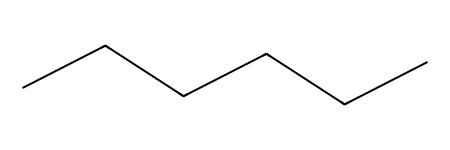

In [53]:
hexane

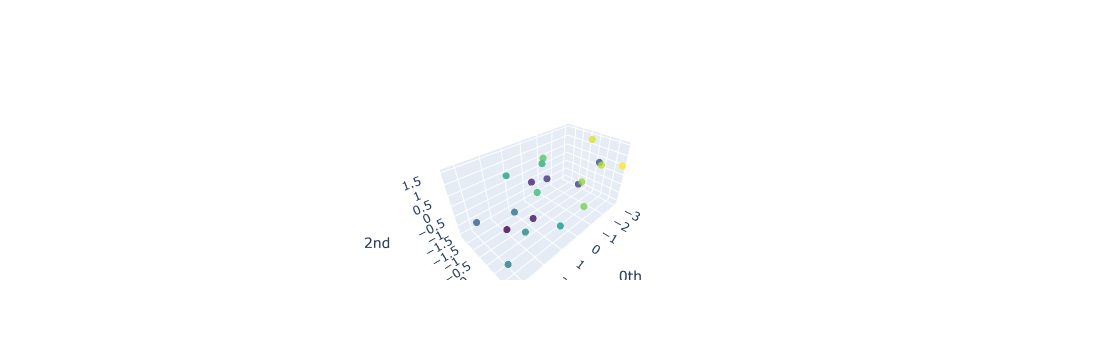

In [54]:
coords, diagrams_basic = smiles_to_persistence_diagrams(hexane_smiles)
plot_point_cloud(coords)

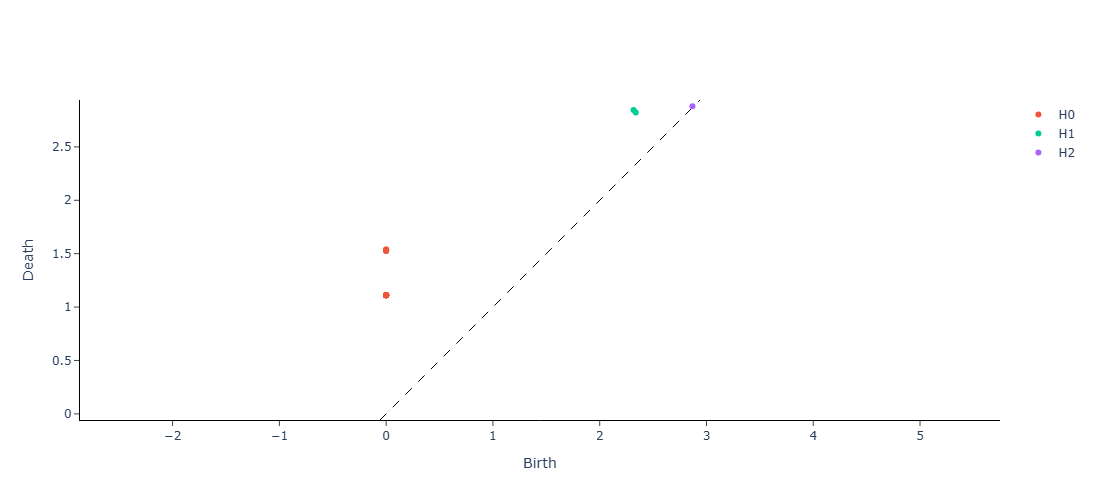

In [55]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

2 lots of 5 bond there (so 6?)

In [56]:
diagrams_basic

array([[[0.        , 1.1097362 , 0.        ],
        [0.        , 1.11003315, 0.        ],
        [0.        , 1.1103878 , 0.        ],
        [0.        , 1.11042237, 0.        ],
        [0.        , 1.11047745, 0.        ],
        [0.        , 1.11063504, 0.        ],
        [0.        , 1.11073792, 0.        ],
        [0.        , 1.11087132, 0.        ],
        [0.        , 1.11094153, 0.        ],
        [0.        , 1.11157715, 0.        ],
        [0.        , 1.1117301 , 0.        ],
        [0.        , 1.11185634, 0.        ],
        [0.        , 1.11192548, 0.        ],
        [0.        , 1.11221099, 0.        ],
        [0.        , 1.52606666, 0.        ],
        [0.        , 1.5281961 , 0.        ],
        [0.        , 1.53550184, 0.        ],
        [0.        , 1.53908324, 0.        ],
        [0.        , 1.53938711, 0.        ],
        [2.33765936, 2.82319808, 1.        ],
        [2.31693721, 2.84624672, 1.        ],
        [2.86842489, 2.8816576 , 2

## S-alanine
No difference between S and D alanine, as chirality is not conserved in topologuy

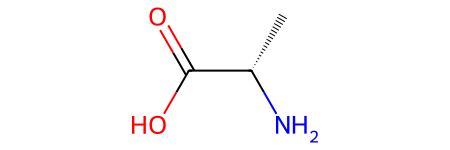

In [57]:
S_alanine

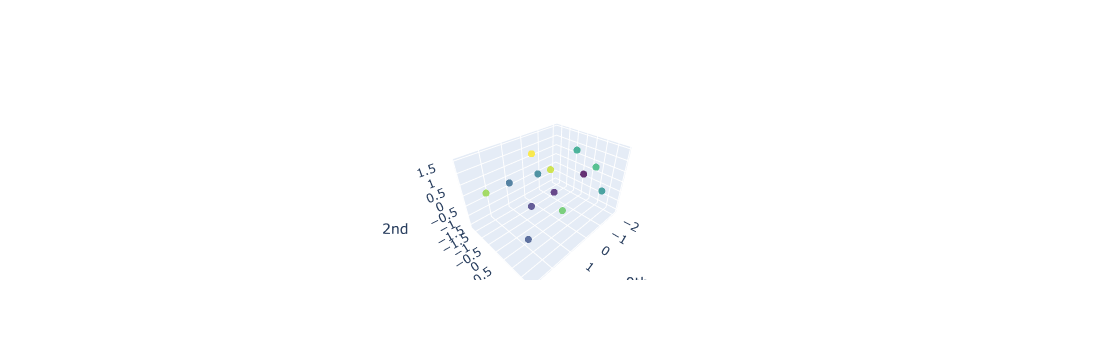

In [58]:
coords, diagrams_basic = smiles_to_persistence_diagrams(S_alanine_smiles)
plot_point_cloud(coords)

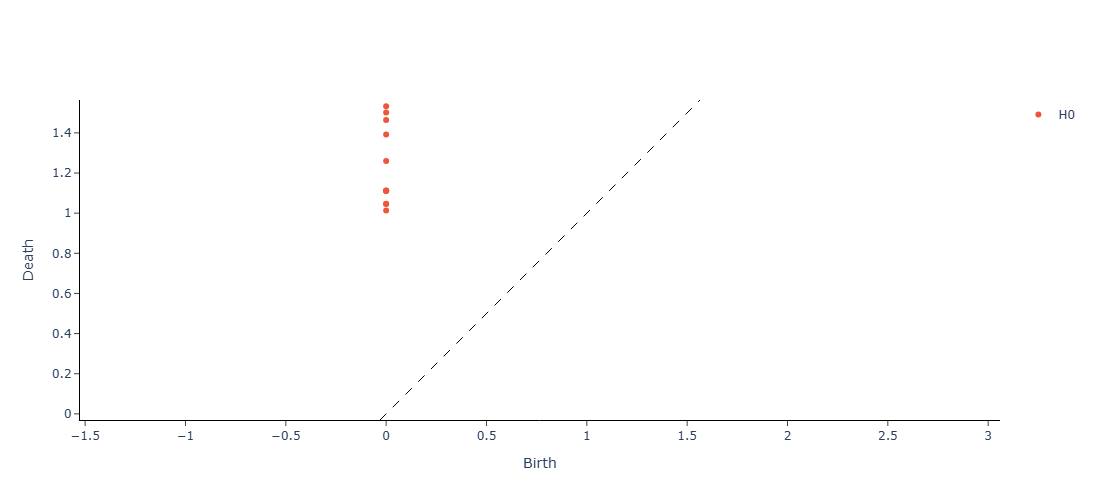

In [59]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

In [60]:
diagrams_basic

array([[[0.        , 1.01297235, 0.        ],
        [0.        , 1.04616523, 0.        ],
        [0.        , 1.04665756, 0.        ],
        [0.        , 1.11067927, 0.        ],
        [0.        , 1.11114252, 0.        ],
        [0.        , 1.11129653, 0.        ],
        [0.        , 1.11333823, 0.        ],
        [0.        , 1.26026988, 0.        ],
        [0.        , 1.3921895 , 0.        ],
        [0.        , 1.46396863, 0.        ],
        [0.        , 1.5012629 , 0.        ],
        [0.        , 1.53328156, 0.        ],
        [0.        , 0.        , 1.        ],
        [0.        , 0.        , 2.        ]]])

In [61]:
S_Ala=diagrams_basic

## D-alanine


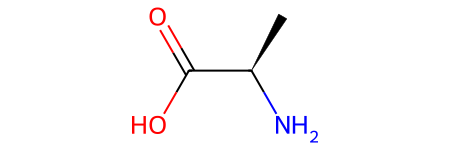

In [62]:
D_alanine

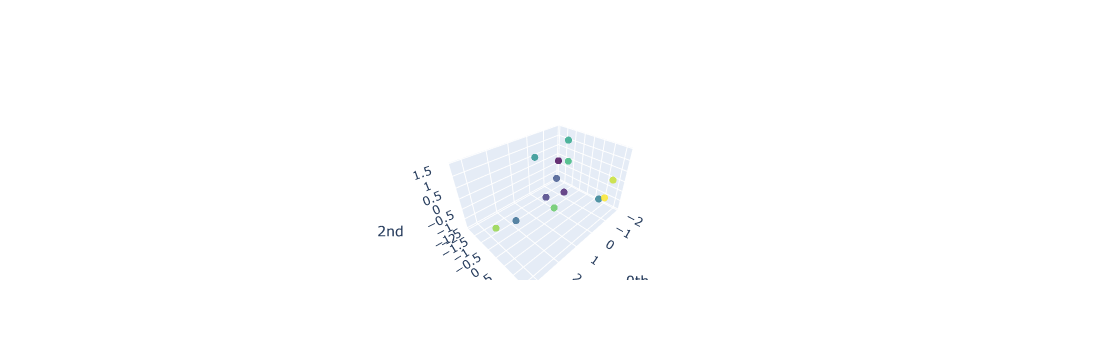

In [63]:
coords, diagrams_basic = smiles_to_persistence_diagrams(D_alanine_smiles)
plot_point_cloud(coords)

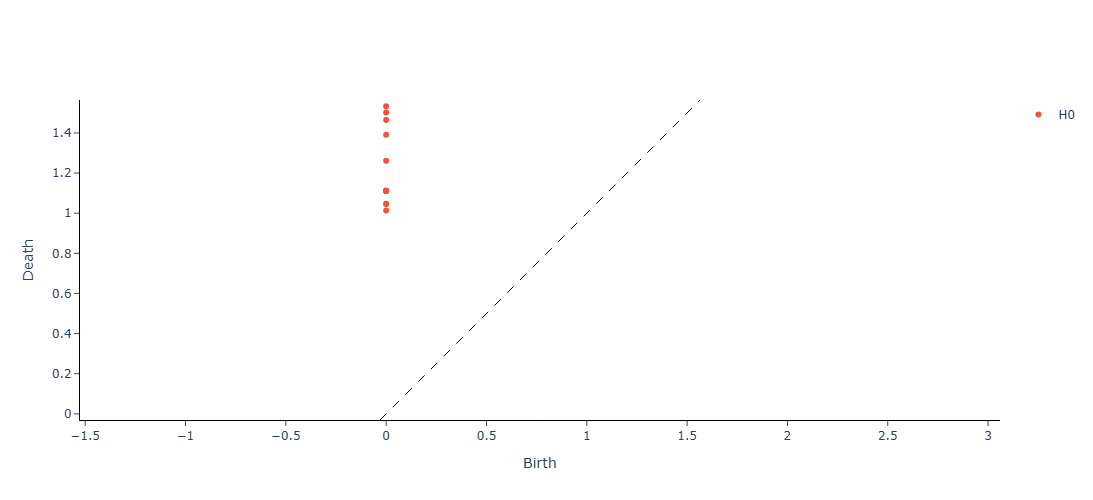

In [64]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

The blob is still present but has no x,y coords so not on the plot, I have no idea what this means

In [65]:
diagrams_basic

array([[[0.        , 1.01302314, 0.        ],
        [0.        , 1.04615843, 0.        ],
        [0.        , 1.04664826, 0.        ],
        [0.        , 1.11067259, 0.        ],
        [0.        , 1.11114109, 0.        ],
        [0.        , 1.11127484, 0.        ],
        [0.        , 1.11270618, 0.        ],
        [0.        , 1.26087511, 0.        ],
        [0.        , 1.39149475, 0.        ],
        [0.        , 1.46433294, 0.        ],
        [0.        , 1.50144076, 0.        ],
        [0.        , 1.53358626, 0.        ],
        [0.        , 0.        , 1.        ],
        [0.        , 0.        , 2.        ]]])

In [66]:
D_Ala=diagrams_basic

In [67]:
S_Ala - D_Ala

array([[[ 0.00000000e+00, -5.07831573e-05,  0.00000000e+00],
        [ 0.00000000e+00,  6.79492950e-06,  0.00000000e+00],
        [ 0.00000000e+00,  9.29832458e-06,  0.00000000e+00],
        [ 0.00000000e+00,  6.67572021e-06,  0.00000000e+00],
        [ 0.00000000e+00,  1.43051147e-06,  0.00000000e+00],
        [ 0.00000000e+00,  2.16960907e-05,  0.00000000e+00],
        [ 0.00000000e+00,  6.32047653e-04,  0.00000000e+00],
        [ 0.00000000e+00, -6.05225563e-04,  0.00000000e+00],
        [ 0.00000000e+00,  6.94751740e-04,  0.00000000e+00],
        [ 0.00000000e+00, -3.64303589e-04,  0.00000000e+00],
        [ 0.00000000e+00, -1.77860260e-04,  0.00000000e+00],
        [ 0.00000000e+00, -3.04698944e-04,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]])

 There is not a significant difference between the isomers, so chirality is not preserved in topology.

## Cyclohexane boat / chair

# boat first!

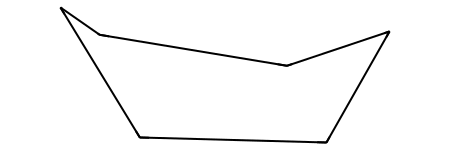

In [165]:
rdkit.Chem.rdmolfiles.MolFromPDBFile(os.path.join(data_dir, r"cyclohexane_boat.pdb"))

In [166]:
coords = generate_structure_from_pdb(filename="cyclohexane_boat.pdb", data_dir=data_dir)

In [167]:
coords, diagrams_basic = coords_to_persistence_diagrams(coords)

In [168]:
plot_point_cloud(coords)

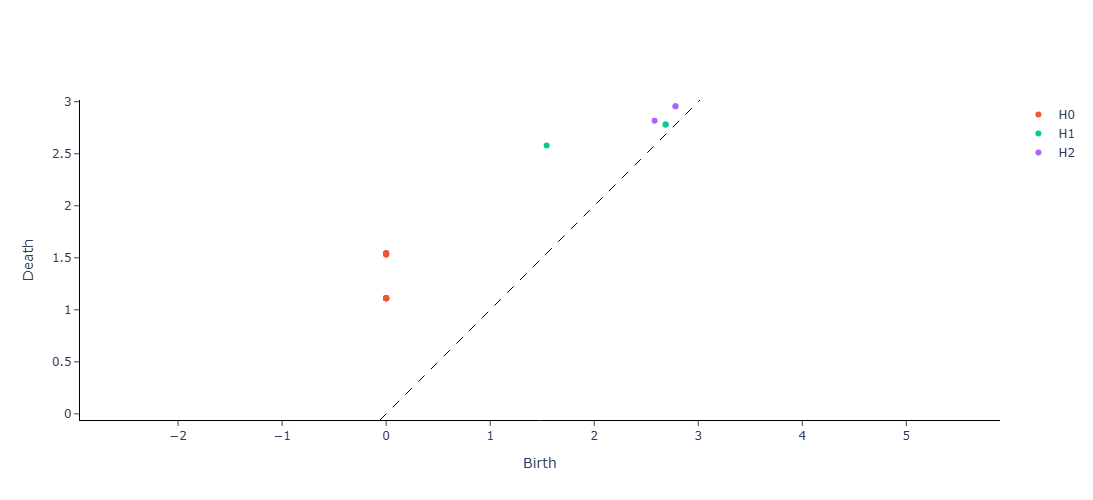

In [169]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

In [170]:
diagrams_basic

array([[[0.        , 1.1114502 , 0.        ],
        [0.        , 1.11145043, 0.        ],
        [0.        , 1.11145055, 0.        ],
        [0.        , 1.11145067, 0.        ],
        [0.        , 1.11186039, 0.        ],
        [0.        , 1.11186039, 0.        ],
        [0.        , 1.11186063, 0.        ],
        [0.        , 1.11186063, 0.        ],
        [0.        , 1.112463  , 0.        ],
        [0.        , 1.11246324, 0.        ],
        [0.        , 1.11246336, 0.        ],
        [0.        , 1.11246336, 0.        ],
        [0.        , 1.5321635 , 0.        ],
        [0.        , 1.53216386, 0.        ],
        [0.        , 1.54252326, 0.        ],
        [0.        , 1.54252338, 0.        ],
        [0.        , 1.54252362, 0.        ],
        [2.68609643, 2.78113866, 1.        ],
        [2.68607926, 2.78113961, 1.        ],
        [1.54252362, 2.5800674 , 1.        ],
        [2.7811408 , 2.95750737, 2.        ],
        [2.78114033, 2.95751643, 2

In [172]:
boat_diag_basic = diagrams_basic
len(boat_diag_basic[0])

23

## Cyclohexane chair

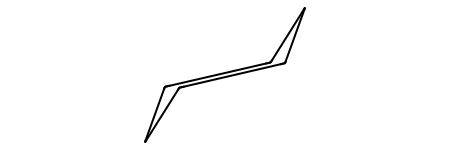

In [173]:
rdkit.Chem.rdmolfiles.MolFromPDBFile(os.path.join(data_dir, r"cyclohexane_chair.pdb"))

In [174]:
coords = generate_structure_from_pdb(filename="cyclohexane_chair.pdb", data_dir=data_dir)

In [175]:
coords, diagrams_basic = coords_to_persistence_diagrams(coords)

In [176]:
plot_point_cloud(coords)

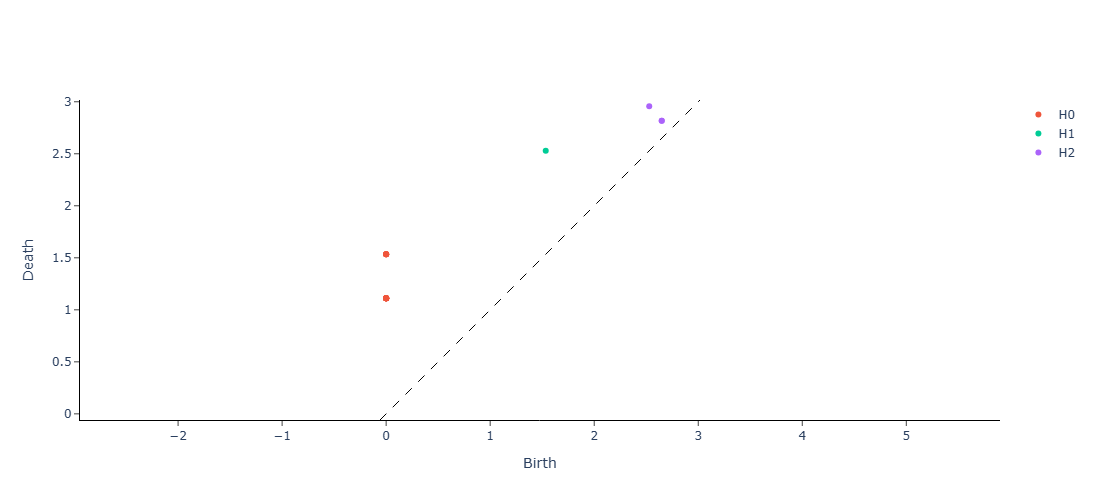

In [177]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

In [178]:
diagrams_basic

array([[[0.        , 1.11122704, 0.        ],
        [0.        , 1.11122704, 0.        ],
        [0.        , 1.11122704, 0.        ],
        [0.        , 1.11122704, 0.        ],
        [0.        , 1.11122704, 0.        ],
        [0.        , 1.11122715, 0.        ],
        [0.        , 1.11231899, 0.        ],
        [0.        , 1.11231899, 0.        ],
        [0.        , 1.11231899, 0.        ],
        [0.        , 1.11231899, 0.        ],
        [0.        , 1.11231899, 0.        ],
        [0.        , 1.11231899, 0.        ],
        [0.        , 1.53396976, 0.        ],
        [0.        , 1.53396976, 0.        ],
        [0.        , 1.53396988, 0.        ],
        [0.        , 1.53396988, 0.        ],
        [0.        , 1.53397012, 0.        ],
        [1.53397012, 2.52883005, 1.        ],
        [2.64887118, 2.81705475, 2.        ],
        [2.64887094, 2.81705475, 2.        ],
        [2.52883005, 2.95770931, 2.        ]]])

In [179]:
chair_diag_basic = diagrams_basic
print(len(boat_diag_basic[0]))
len(chair_diag_basic[0])

23


21

The two digrams have different numbers of points so obviously are different, therefore persistence homology is sensitive to diffenet configurations.

# Buckyball

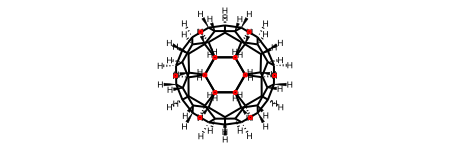

In [180]:
rdkit.Chem.rdmolfiles.MolFromPDBFile(os.path.join(data_dir, r"c_60.pdb"))


In [186]:
coords = generate_structure_from_pdb(filename="c_60.pdb", data_dir=data_dir)

In [187]:
coords, diagrams_basic = coords_to_persistence_diagrams(coords)

In [188]:
plot_point_cloud(coords)

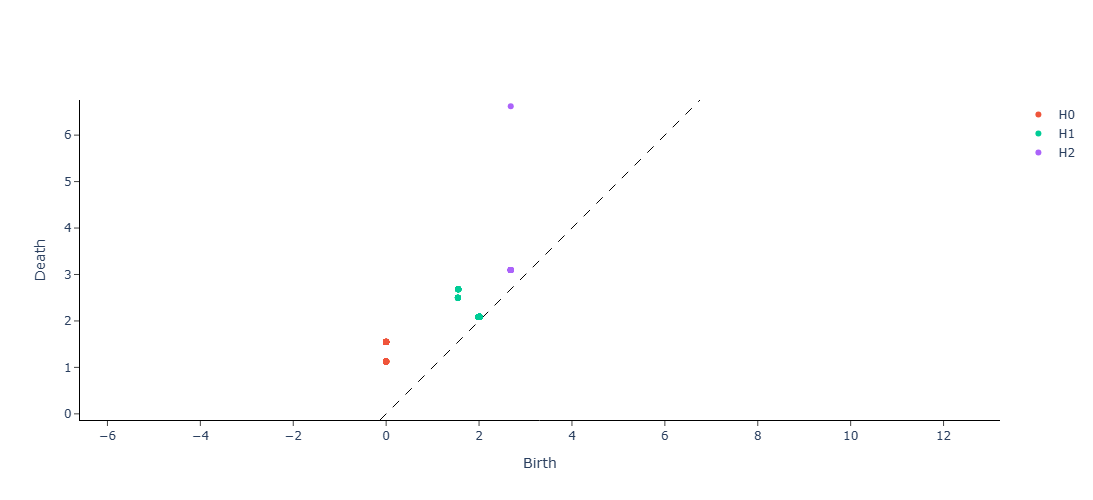

In [189]:
# Circle shape persistence diagram
plot_diagram(diagrams_basic[0])

In [190]:
diagrams_basic

array([[[0.        , 1.12679553, 0.        ],
        [0.        , 1.12679982, 0.        ],
        [0.        , 1.12681007, 0.        ],
        [0.        , 1.12681067, 0.        ],
        [0.        , 1.12681091, 0.        ],
        [0.        , 1.12681329, 0.        ],
        [0.        , 1.12681341, 0.        ],
        [0.        , 1.12681437, 0.        ],
        [0.        , 1.12681544, 0.        ],
        [0.        , 1.12681639, 0.        ],
        [0.        , 1.12681651, 0.        ],
        [0.        , 1.12681711, 0.        ],
        [0.        , 1.12681818, 0.        ],
        [0.        , 1.12681913, 0.        ],
        [0.        , 1.12681973, 0.        ],
        [0.        , 1.12682009, 0.        ],
        [0.        , 1.12682009, 0.        ],
        [0.        , 1.12682045, 0.        ],
        [0.        , 1.1268208 , 0.        ],
        [0.        , 1.12682104, 0.        ],
        [0.        , 1.12682188, 0.        ],
        [0.        , 1.12682223, 0

In [192]:
len(diagrams_basic[0])

261

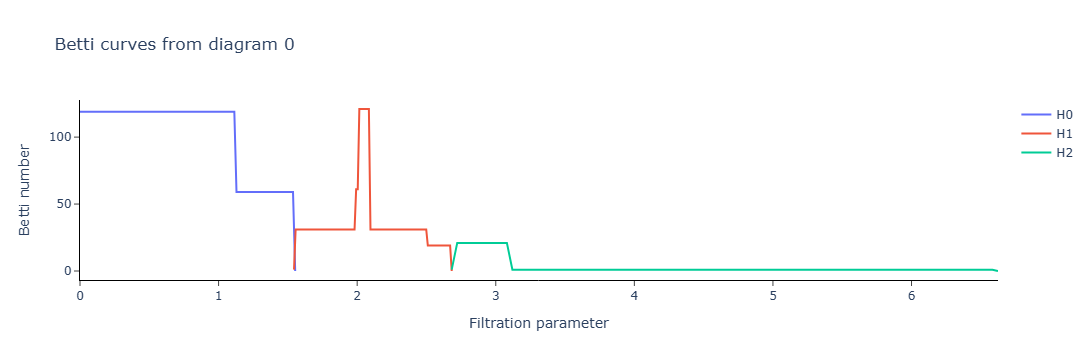

In [193]:

X_betti_curves = BC.fit_transform(diagrams_basic)

BC.plot(X_betti_curves)